# Mixed-polyhedral Mesh for East Fork Poplar Creek

In [30]:
# these can be turned on for development work
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This notebooks should be used with ssr/v1.4 branch. This branch is same as v1.4 + minor change in the merge functions

In [31]:
## Importing all the package needed to run teh watershed workflow
# conda package imports
import os,sys
import numpy as np
import pandas
from matplotlib import pyplot as plt
import logging
import pandas as pd
import seaborn as sns
import copy
import scipy
import shapely

sys.path.append('/Users/7s2/Softwares/ats_input_spec') 
%set_env AMANZI_SRC_DIR=/Users/7s2/Softwares/ats_1.3/ats/repos/amanzi
%set_env ATS_SRC_DIR=/Users/7s2/Softwares/ats_1.3/ats/repos/amanzi/src/physics/ats
sys.path.append('/Users/7s2/Softwares/ats_1.3/ats/repos/amanzi/tools/amanzi_xml')


import watershed_workflow 
import watershed_workflow.source_list
import watershed_workflow.ui
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.daymet
import watershed_workflow.densification
import watershed_workflow.condition
import watershed_workflow.regions

watershed_workflow.ui.setup_logging(1,None)

# # ats_input_spec library, to be moved to amanzi_xml
# import ats_input_spec
# import ats_input_spec.public
# import ats_input_spec.io

# # amanzi_xml, included in AMANZI_SRC_DIR/tools/amanzi_xml
# import amanzi_xml.utils.io as aio
# import amanzi_xml.utils.search as asearch
# import amanzi_xml.utils.errors as aerrors

env: AMANZI_SRC_DIR=/Users/7s2/Softwares/ats_1.3/ats/repos/amanzi
env: ATS_SRC_DIR=/Users/7s2/Softwares/ats_1.3/ats/repos/amanzi/src/physics/ats


In [32]:
# Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed.
hucs = ['060102070302']
name = "efpc"
huc_level = None # if provided, an int setting the level at which to include HUC boundaries
modis_name = 'efpc'
daymet_name= 'efpc'

# geometric parameters
simplify = 100 # length scale to target average edge
simplify_rivers = 100
stream_outlet_width = 500 # half-width to track a labeled set on which to get discharge
ignore_small_rivers = 2 # ignore rivers which have this or fewer reaches.  likely they are irrigation ditches
                        # or other small features which make things complicated but likely don't add much value
prune_by_area_fraction = 0.001 # ignore reaches whose accumulated catchment area is less than this fraction of the
                              # full domain's area
prune_by_area_fraction_waterbodies = None
num_smoothing_sweeps = 5 # number of times to smooth the DEM prior to elevating

# simulation control
start_year = 2005  # year to start and end simulation simulation -- note these start and end Oct 1 of the year
end_year = 2020
min_porosity = 0.05 # minimum porosity considered too small
max_permeability = 1.e-10 # max value allowed for permeability
max_vg_alpha = 1.e-3 # max value of van Genuchten's alpha -- our correlation is not valid for some soils

# triangle refinement control
include_rivers = True
refine_d0 = 100
refine_d1 = 500
refine_A0 = 8000
refine_A1 = 50000

# soil structure
use_geologic_layer = True

# logistics
generate_plots = True # plots take time to make and aren't always needed
generate_daymet = True # potentially don't do Met data forcing
generate_modis = True

include_heterogeneous = True
include_homogeneous = False # if true, also write files for homogeneous runs
include_homogeneous_wrm = False # if true, also write files for homogeneous WRMs
include_homogeneous_wrm_porosity = False # if true, also write files for homogeneous porosity and WRMs
include_homogeneous_wrm_permeability = False # if true, also write files for homogeneous perm and WRMs

log_to_file = False  # if true, write to file instead of in the notebook output
figsize = (6,6)
figsize_3d = (8,6)

In [33]:
# parameter checking
assert(simplify > 0 and simplify < 300)
assert(ignore_small_rivers == None or (ignore_small_rivers >= 0 and ignore_small_rivers <= 100))
assert(prune_by_area_fraction == None or (prune_by_area_fraction >= 0 and prune_by_area_fraction < 1))
assert(start_year >= 1980 and start_year < 2020)

if type(hucs) is str:
    assert(hucs[0] == '[')
    assert(hucs[-1] == ']')
    hucs = hucs[1:-1]
    hucs = hucs.split(',')
    hucs = [h.strip() for h in hucs]
    if hucs[-1] == '':
        hucs = hucs[:-1]

if huc_level is None:
    huc_level = len(hucs[0])
else:
    assert(huc_level >= len(hucs[0]))
huc_key = f'HUC{huc_level}'

if prune_by_area_fraction_waterbodies is None:
    prune_by_area_fraction_waterbodies = prune_by_area_fraction * 0.1


In [34]:
# a dictionary of outputs -- will include all filenames generated
outputs = {}

In [35]:
# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.daymet_crs()

In [36]:

# find the corresponding reaches
def find_reaches(rivers, ids):
    reaches = []
    for nhdid in ids:
        found = False
        for river in rivers:
            n = river.getNode(nhdid)
            if n is not None:
                found = True
                reaches.append(n)
                break
        if not found:
            reaches.append(None)
    return reaches


## Sources and setup

Next we set up the source watershed and coordinate system and all data sources for our mesh.  We will use the CRS that is included in the shapefile.

In [37]:
logging.info("")
logging.info(f"Meshing shape: {hucs}")
logging.info("="*30)

2024-03-06 19:28:52,117 - root - INFO: 
2024-03-06 19:28:52,118 - root - INFO: Meshing shape: ['060102070302']
2024-03-06 19:28:52,118 - root - INFO: ==============================


In [38]:
# set up a dictionary of source objects
sources = watershed_workflow.source_list.get_default_sources()
sources['hydrography'] = watershed_workflow.source_list.hydrography_sources['NHD Plus']
sources['HUC'] = watershed_workflow.source_list.huc_sources['NHD Plus']
sources['DEM'] = watershed_workflow.source_list.dem_sources['NED 1/3 arc-second']
watershed_workflow.source_list.log_sources(sources)

2024-03-06 19:28:52,165 - root - INFO: Using sources:
2024-03-06 19:28:52,166 - root - INFO: --------------
2024-03-06 19:28:52,166 - root - INFO: HUC: National Hydrography Dataset Plus High Resolution (NHDPlus HR)
2024-03-06 19:28:52,167 - root - INFO: hydrography: National Hydrography Dataset Plus High Resolution (NHDPlus HR)
2024-03-06 19:28:52,167 - root - INFO: DEM: National Elevation Dataset (NED)
2024-03-06 19:28:52,168 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2024-03-06 19:28:52,168 - root - INFO: geologic structure: GLHYMPS version 2.0
2024-03-06 19:28:52,168 - root - INFO: land cover: National Land Cover Database (NLCD) Layer: NLCD_2019_Land_Cover_L48
2024-03-06 19:28:52,168 - root - INFO: lai: MODIS


2024-03-06 19:28:52,169 - root - INFO: soil thickness: None
2024-03-06 19:28:52,169 - root - INFO: meteorology: DayMet 1km


In [39]:
watershed_containing_basin.area

70982375.15883334

In [40]:
# load the huc
my_hucs = []
for huc in hucs:
    _, ws = watershed_workflow.get_huc(sources['HUC'], huc, crs)
    my_hucs.append(ws)

watershed_containing_basin = shapely.ops.cascaded_union(my_hucs)

2024-03-06 19:28:52,280 - root - INFO: 
2024-03-06 19:28:52,281 - root - INFO: Loading HUC 060102070302
2024-03-06 19:28:52,281 - root - INFO: ------------------------------
2024-03-06 19:28:52,282 - root - INFO: 
2024-03-06 19:28:52,282 - root - INFO: Loading level 12 HUCs in 060102070302
2024-03-06 19:28:52,283 - root - INFO: ------------------------------


2024-03-06 19:28:52,284 - root - INFO: Using HUC file "/Users/7s2/Research/watershed_workflow_data/hydrography/NHDPlus_H_0601_GDB/NHDPlus_H_0601.gdb"
2024-03-06 19:28:52,363 - root - INFO: ... found 1 HUCs
2024-03-06 19:28:52,364 - root - INFO:   -- 060102070302
2024-03-06 19:28:52,369 - root - INFO: Converting to out_crs
2024-03-06 19:28:52,378 - root - INFO: Converting to shapely
2024-03-06 19:28:52,379 - root - INFO:  ... done
2024-03-06 19:28:52,379 - root - INFO: ... found 1


## Generate the surface mesh

First we'll generate the flattened, 2D triangulation, which builds on hydrography data.  Then we download a digital elevation map from the National Elevation Dataset, and extrude that 2D triangulation to a 3D surface mesh based on interpolation between pixels of the DEM.

### Get river network

This will download the river network from the NHD Plus database, and simplify the network, constructing a tree-like data structure.

In [41]:
# what about the reservoir!
_, waterbodies = watershed_workflow.get_waterbodies(sources['hydrography'], huc, my_hucs[0], crs, crs, 
                                                    prune_by_area=prune_by_area_fraction_waterbodies*my_hucs[0].area)

2024-03-06 19:28:52,425 - root - INFO: 
2024-03-06 19:28:52,426 - root - INFO: Loading Water Bodies
2024-03-06 19:28:52,426 - root - INFO: ------------------------------
2024-03-06 19:28:52,427 - root - INFO: Loading waterbodies in HUC 060102070302
2024-03-06 19:28:52,427 - root - INFO:          and/or bounds (1345772.6458075882, -571056.2786547501, 1358722.0666446937, -558489.114717032)
2024-03-06 19:28:52,428 - root - INFO:   Using Hydrography file "/Users/7s2/Research/watershed_workflow_data/hydrography/NHDPlus_H_0601_GDB/NHDPlus_H_0601.gdb"


2024-03-06 19:28:52,428 - root - INFO:   National Hydrography Dataset Plus High Resolution (NHDPlus HR): opening '/Users/7s2/Research/watershed_workflow_data/hydrography/NHDPlus_H_0601_GDB/NHDPlus_H_0601.gdb' layer 'NHDWaterbody' for streams in '(1345772.6458075882, -571056.2786547501, 1358722.0666446937, -558489.114717032)'
2024-03-06 19:28:52,547 - root - INFO:   Found total of 171 in bounds.
2024-03-06 19:28:52,547 - root - INFO: ... found 171 waterbodies
2024-03-06 19:28:52,548 - root - INFO: Converting to shapely
2024-03-06 19:28:52,573 - root - INFO:  ... done
2024-03-06 19:28:52,574 - root - INFO: Converting to out_crs
2024-03-06 19:28:52,574 - root - INFO:   epsg:4269
2024-03-06 19:28:52,574 - root - INFO:   +proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs +type=crs
2024-03-06 19:28:52,601 - root - INFO:  ... done
2024-03-06 19:28:52,610 - root - INFO: Removed 120 of 171 water bodies not in shape
2024-03-06 19:28:52,614 - root -

In [42]:
include_rivers=True

if include_rivers:  
    # download/collect the river network within that shape's bounds
    _, reaches_raw = watershed_workflow.get_reaches(sources['hydrography'], "0601", 
                                                watershed_containing_basin, crs, crs,
                                                in_network=True, properties=True, include_catchments=True)
    
    rivers_raw = watershed_workflow.construct_rivers(reaches_raw, method='hydroseq',
                                                 ignore_small_rivers=ignore_small_rivers,
                                                 prune_by_area=prune_by_area_fraction*watershed_containing_basin.area*1e-6,
                                                 remove_diversions=True,
                                                 remove_braided_divergences=True)

2024-03-06 19:28:52,660 - root - INFO: 
2024-03-06 19:28:52,661 - root - INFO: Loading Hydrography
2024-03-06 19:28:52,661 - root - INFO: ------------------------------
2024-03-06 19:28:52,661 - root - INFO: Loading streams in HUC 0601
2024-03-06 19:28:52,662 - root - INFO:          and/or bounds (1345772.6458075882, -571056.2786547501, 1358722.0666446937, -558489.114717032)
2024-03-06 19:28:52,662 - root - INFO:   Using Hydrography file "/Users/7s2/Research/watershed_workflow_data/hydrography/NHDPlus_H_0601_GDB/NHDPlus_H_0601.gdb"


2024-03-06 19:28:52,662 - root - INFO:   National Hydrography Dataset Plus High Resolution (NHDPlus HR): opening '/Users/7s2/Research/watershed_workflow_data/hydrography/NHDPlus_H_0601_GDB/NHDPlus_H_0601.gdb' layer 'NHDFlowline' for streams in '(1345772.6458075882, -571056.2786547501, 1358722.0666446937, -558489.114717032)'
2024-03-06 19:28:53,526 - root - INFO:   Found total of 984 in bounds.
2024-03-06 19:28:53,526 - root - INFO:   Filtering reaches not in-network
2024-03-06 19:28:53,527 - root - INFO:   National Hydrography Dataset Plus High Resolution (NHDPlus HR): opening '/Users/7s2/Research/watershed_workflow_data/hydrography/NHDPlus_H_0601_GDB/NHDPlus_H_0601.gdb' layer 'NHDPlusCatchment' for catchments in '(-84.39432941096388, 35.910025733876154, -84.22046049575718, 36.04849570472191)'
2024-03-06 19:29:02,456 - root - INFO: ... found 984 reaches
2024-03-06 19:29:02,456 - root - INFO: Converting to shapely
2024-03-06 19:29:02,496 - root - INFO:  ... done
2024-03-06 19:29:02,497 

<b> We have a smaller river disconnected from the main river, we inject this smaller river into the bigger one </b>

In [43]:
node1 = rivers_raw[1].getNode('25000400136189')
node2 = rivers_raw[0].getNode('25000400102585')

end_point=shapely.geometry.Point(node1.segment.coords[-1])

p2 = shapely.geometry.Point(watershed_workflow.utils.nearest_point(node2.segment, end_point))
seg = node2.segment
seg.distance(p2) < 1e-8
result = shapely.ops.split(seg, p2.buffer(0.01))
result_sorted = (sorted(list(result), key=lambda x: watershed_workflow.utils.distance(seg.coords[0],x.coords[0]), reverse=True))
for seg in result_sorted:
    seg.properties = copy.deepcopy(node2.properties)

## for parent node
seg =shapely.geometry.LineString(end_point.coords[:]+result_sorted[0].coords[1:])
seg.properties = node2.properties
node2.segment=seg

# child
seg=shapely.geometry.LineString(result_sorted[-1].coords[:-1]+end_point.coords[:])
seg.properties = copy.deepcopy(node2.properties) # testing this
seg.properties['HydrologicSequence'] = seg.properties['HydrologicSequence'] +0.5 ## this hack is needed for hydrologic consistency 
seg.properties['ID'] = seg.properties['ID'] +'b'
# seg.properties['Name'] = seg.properties['Name']+"_ext."
node2.inject(watershed_workflow.river_tree.River(seg))
node2.addChild(node1)

rivers_raw = [rivers_raw[0]]

/Users/7s2/opt/anaconda3/envs/watershed_workflow-2024-Jan/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


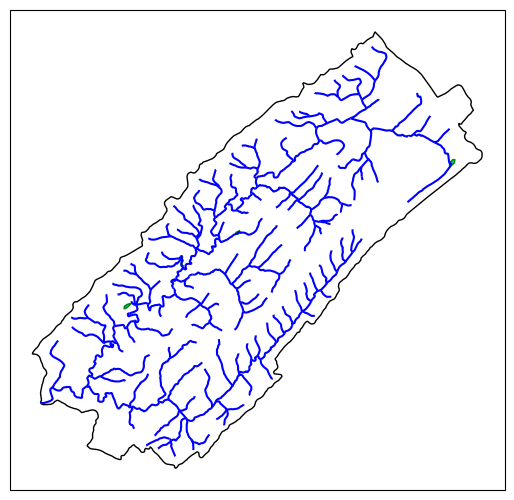

In [44]:
if generate_plots:
    fig = plt.figure(figsize=figsize)
    ax = watershed_workflow.plot.get_ax(crs, fig, window=[0.05,0.1,0.9,0.8])    
    watershed_workflow.plot.shply(watershed_containing_basin, crs, 'k', ax)
    watershed_workflow.plot.rivers(rivers_raw, crs, ['b'], ax)
    watershed_workflow.plot.shplys(waterbodies, crs, 'g', ax, facecolor='c')
    plt.show()

In [48]:
watershed_workflow.io.write_to_shapefile('efpc_boundary',[watershed_containing_basin], crs)

### Getting watersheds based on spill/outlet points

In [ ]:
nhdids = ['25000400169624', '25000400136040', '25000400102432']
names = ['efpc upstream', 'bear creek', 'efpc downstream']

for id, name in zip(nhdids, names):
    print(id, name)

In [ ]:
def getNode(nhd_id , rivers):
    node = next(river.getNode(nhd_id) for river in rivers if river.getNode(nhd_id) != None)
    return node

def get_subDomain(id, subdomains):
    subdomain_index = next((index, subdomain) for index, subdomain in enumerate(subdomains) if subdomain.properties['outlet_ID'] == id)
    index, subdomain = subdomain_index
    return index, subdomain

## Subdomain generation

### Get river network

This will download the river network from the NHD Plus database, and simplify the network, constructing a tree-like data structure.

In [ ]:
# now that we are done modifying, we must compute our own contributing areas on this new network
for river in rivers_raw:
    river.accumulate('CatchmentAreaSqKm', to_save='ContributingAreaSqKm')

# reset the reaches raw, now that we are done manipulating
reaches_raw = [r for river in rivers_raw for r in river]

In [ ]:
# make a copy of the rivers_raw and compute pruned rivers
rivers = [r.deepcopy() for r in rivers_raw]

# note the conversion to sq km, because the default property is TotalDrainageAreaSqKm which is in km^2
rivers = watershed_workflow.reduce_rivers(rivers,
                                          ignore_small_rivers=ignore_small_rivers,
                                          prune_by_area=(prune_by_area_fraction * 
                                                            watershed_containing_basin.area * 1.e-6),
                                          area_property='ContributingAreaSqKm',
                                          remove_diversions=True,
                                          remove_braided_divergences=True)
print(len(rivers))
print(len(rivers[0]))

### Partition the domain into nonoverlapping subdomains

In [ ]:
trunk_reaches = find_reaches(rivers_raw, nhdids)
assert(all(tr is not None for tr in trunk_reaches))

trunk_reaches_pruned = find_reaches(rivers, nhdids)
assert(all(tr is not None for tr in trunk_reaches))
print([i for (i,tr) in enumerate(trunk_reaches_pruned) if tr is None])

In [ ]:
# define domains that are the accumulated area of these trunk reaches
trunk_reaches, incremental_cas = watershed_workflow.river_tree.accumulateIncrementalCatchments(rivers_raw, nhdids, names)

# # form a list of the rivers that are not used in trunk_reaches -- this will be used to fill the holes
# rivers_not_touched = rivers[:]
# for tr_root in set([tr.getRoot() for tr in trunk_reaches]):
#     rivers_not_touched.remove(tr_root)


In [ ]:
# some contributing areas are discontinuous -- this is physically wrong, but what can you do?
incremental_cas2 = []
for poly in incremental_cas:
    if isinstance(poly, shapely.geometry.Polygon):
        incremental_cas2.append(poly)
    else:
        incremental_cas2.append(watershed_workflow.split_hucs.biggest(poly))
        incremental_cas2[-1].properties = poly.properties
incremental_cas = incremental_cas2

In [ ]:
# sort the trunks by CA size -- this isn't needed but allows for nicer plots later
sorted_pairs = sorted(zip(trunk_reaches, trunk_reaches_pruned, incremental_cas), key=lambda a : a[0].properties['ContributingAreaSqKm'], reverse=True)
trunk_reaches = [i[0] for i in sorted_pairs]
trunk_reaches_pruned = [i[1] for i in sorted_pairs]
incremental_cas = [i[2] for i in sorted_pairs]

assert(all(hasattr(poly, 'properties') for poly in incremental_cas))
assert(all(isinstance(poly, shapely.geometry.Polygon) for poly in incremental_cas))

In [ ]:
subdomains = watershed_workflow.utils.deepcopy(incremental_cas)

fig, ax = watershed_workflow.plot.get_ax(crs)
watershed_workflow.plot.shply(watershed_containing_basin, crs, 'r', ax)
watershed_workflow.plot.shplys(subdomains, crs, None, ax, facecolor='edge', alpha=0.8)

In [ ]:
# automatically clean up holes on the interior or exterior boundary
subdomains, holes = watershed_workflow.split_hucs.removeHoles(subdomains)

print(len(holes))
fig, ax =  watershed_workflow.plot.get_ax(crs)
watershed_workflow.plot.shply(watershed_containing_basin, crs, 'r', ax)
watershed_workflow.plot.shplys(subdomains, crs, None, ax, facecolor='edge', alpha=0.8)

In [ ]:
# get the missing areas
all_subdomains = shapely.ops.unary_union(subdomains)
missing_regions = watershed_containing_basin.difference(all_subdomains)
print(len(missing_regions))
missing_regions = [mr for mr in missing_regions if mr.area > 500]
print(len(missing_regions))

In [ ]:
fig, ax = watershed_workflow.plot.get_ax(crs)

watershed_workflow.plot.shply(watershed_containing_basin, crs, 'r', ax)
watershed_workflow.plot.shplys(subdomains, crs, None, ax, facecolor='edge', alpha=0.8)
watershed_workflow.plot.shplys(missing_regions, crs, 'k', ax, alpha=0.8)


In [ ]:


# lots of small holes arounf the edge mostly due to using HR for overall watershed_containing_basin and V2 for subdomains
# let us now update watershed_containing_basin sicne it was built using NHDPlusHR. We are doing this 
watershed_containing_basin = shapely.geometry.Polygon(all_subdomains.exterior)


# # get the missing areas
# all_subdomains = shapely.ops.unary_union(subdomains)
# missing_regions = watershed_containing_basin.difference(all_subdomains)
# print(len(missing_regions))


In [ ]:
to_cleanup = []
for k,mr in enumerate(missing_regions):
    mr_buffer = mr.buffer(1.e-6)
    intersections = [i for (i,subdomain) in enumerate(subdomains) if mr_buffer.intersection(subdomain).area > 0]
    count = len(intersections)
    #print(k,count)
    if count == 1:
        my_i = intersections[0]
        props = subdomains[my_i].properties
        subdomains[my_i] = shapely.ops.unary_union([subdomains[my_i], mr_buffer])
        subdomains[my_i].properties = props
        print(f'{k} is entirely contained in subdomain {my_i}')
    else:
        to_cleanup.append(mr)
        print(f'{k} is on {count} boundaries, {intersections}')

# note that the internal boundary and internal ones should already be done.  
# So should just be those with count == 1
#assert(len(to_cleanup) == 0)
assert(all(isinstance(poly, shapely.geometry.Polygon) for poly in subdomains))
assert(all(hasattr(poly, 'properties') for poly in subdomains))
print(len(to_cleanup))

In [ ]:
fig, ax = watershed_workflow.plot.get_ax(crs)

watershed_workflow.plot.shply(watershed_containing_basin, crs, 'r', ax)
watershed_workflow.plot.shplys(subdomains, crs, None, ax, facecolor='edge', alpha=0.8)
watershed_workflow.plot.shplys([to_cleanup[0]], crs, 'k', ax, facecolor='k', alpha=1)

In [ ]:
# from visual inspection, the last missing region is to be merged into subdoomain
my_i = 0

props = subdomains[my_i].properties
subdomains[my_i] = shapely.ops.unary_union([subdomains[my_i], to_cleanup[0]])
subdomains[my_i].properties = props

In [ ]:
# keep originals
rivers_orig = [rivers_raw[0]]
reaches_orig = [r for river in rivers_orig for r in river]
subdomains_orig = watershed_workflow.utils.deepcopy(subdomains)
watershed_orig = watershed_workflow.split_hucs.SplitHUCs(subdomains_orig)

In [ ]:
fig, ax = watershed_workflow.plot.get_ax(crs)

watershed_colors = watershed_workflow.colors.enumerated_colors(len(watershed_orig.gons))
watershed_workflow.plot.hucs(watershed_orig, crs,watershed_colors, ax,facecolor='edge', alpha=0.4)

river_colors = watershed_workflow.colors.enumerated_colors(len(rivers))
for i, river in enumerate(rivers):
    watershed_workflow.plot.rivers([river,], crs, river_colors[i], ax, linewidth=1)

# BREAK -- Create Mesh

In [ ]:
# make a copy to preserve originals for restart
subdomains_pristine = subdomains
subdomains = watershed_workflow.utils.deepcopy(subdomains_pristine)
watershed = watershed_workflow.split_hucs.SplitHUCs(subdomains)
# rivers = [rivers[0]]
# reaches = [r for r in rivers]

In [ ]:
rivers=[river.deepcopy() for river in rivers_orig]
watershed=copy.deepcopy(watershed_orig) 

In [ ]:
for river in rivers:
    assert river.is_continuous()
for river in rivers:
    for r in river:
        assert(r.length > 0)

In [ ]:
import ipympl
%matplotlib ipympl


In [ ]:
if generate_plots:
    fig = plt.figure(figsize=figsize)
    ax = watershed_workflow.plot.get_ax(crs, fig, window=[0.05,0.1,0.9,0.8])    
    
    watershed_workflow.plot.hucs(watershed, crs, 'k', ax)
    watershed_workflow.plot.rivers(rivers, crs, 'b', ax)
    watershed_workflow.plot.shplys(waterbodies, crs, 'g', ax, facecolor='c')
    # watershed_workflow.plot.shplys(leaf_tips, crs, 'r', ax)

In [ ]:
rivers = watershed_workflow.simplify(watershed, rivers, 
                                        simplify_hucs=80, simplify_rivers=80, 
                                        snap_tol = 50, merge_tol=50, cut_intersections=True)

# for plotting purpose only
rivers_simplified=[river.deepcopy() for river in rivers] 
watershed_simplified=copy.deepcopy(watershed) 

print('number of reaches in original', len(rivers_orig[0]), 'number of reaches in simplified', len(rivers[0]))

In [ ]:
d0 = 20; d1 = 100
L0 = 75; L1 = 100

# densify_watershed
watershed_workflow.densification.densify_hucs(watershed, watershed_orig, rivers, limit_scales=[d0,L0,d1,L1]) 

#densify_river
watershed_workflow.densification.densify_rivers(rivers, rivers_orig, limit=50)

# treat sharp angles
watershed_workflow.densification.remove_sharp_angles(rivers, watershed, angle_limit=22.5, junction_angle_limit=20, huc_seg_river_angle_limit=10, limit=50)

In [ ]:
%matplotlib inline

In [ ]:
# plotting results
plt.rcParams['figure.figsize'] = [20, 12]

fig, axs = plt.subplots(1,3,subplot_kw={'projection':watershed_workflow.crs.to_cartopy(crs)})

for huc in list(watershed_orig.polygons()):
    axs[0].plot(huc.exterior.xy[0], huc.exterior.xy[1], 'k-x')
axs[0].set_title('original river network and hucs',fontsize=16)
for huc in list(watershed_simplified.polygons()):
    axs[1].plot(huc.exterior.xy[0], huc.exterior.xy[1], 'k-x')
axs[1].set_title('after simplify and prune',fontsize=16)
for huc in list(watershed.polygons()):
    axs[2].plot(huc.exterior.xy[0], huc.exterior.xy[1], 'k-x')
axs[2].set_title('re-densified',fontsize=16)
axs[2].plot()

for river in rivers_orig:
    for node in river.preOrder():
        x,y=node.segment.xy 
        axs[0].plot(x,y,'-o',markersize=2)

for river in rivers_simplified:
    for node in river.preOrder():
        x,y=node.segment.xy 
        axs[1].plot(x,y,'-o',markersize=2)

for river in rivers:
    for node in river.preOrder():
        x,y=node.segment.xy 
        axs[2].plot(x,y,'-o',markersize=2)
plt.show()

In [ ]:
# how many types of Stream Orders are there
set([r.properties["StreamOrder"] for r in rivers[0].preOrder()])

In [ ]:
import seaborn as sns
from matplotlib.lines import Line2D
# how many types of Stream Orders are there
stream_order= set([r.properties["StreamOrder"] for r in rivers[0].preOrder()])
colors_pallete = sns.color_palette(n_colors=len(stream_order))

colors={}
for i, n in enumerate(stream_order):
    colors[str(n)]=colors_pallete[i]
    
plt.rcParams['figure.figsize'] = [5,5]
fig, axs = plt.subplots(1,1,subplot_kw={'projection':watershed_workflow.crs.to_cartopy(crs)})
for segment in  watershed.segments:
    axs.plot(segment.xy[0], segment.xy[1], 'k-x',markersize=2)
axs.set_title('re-densified',fontsize=16)
for river in rivers:
    for i, node in enumerate(river.preOrder()):
        x,y=node.segment.xy 
        axs.plot(x,y,'-o',markersize=2, color=colors[str(node.properties['StreamOrder'])]) 


axs.plot()
# Creating legend entries
legend_entries = [Line2D([0], [0], color=colors[str(order)], marker='o', linestyle='-', markersize=5, label=f'Stream Order {order}')
                  for order in sorted(stream_order)]  # Ensure legend entries are sorted

axs.legend(handles=legend_entries, title="Stream Orders", loc='upper left', fontsize=8)

plt.show()


In [ ]:
## Triangulation

refine_d0 = 40
refine_d1 = 400
refine_A0 = 1000
refine_A1 = 10000

d0 = refine_d0; d1 = refine_d1
A0 = refine_A0; A1 = refine_A1 

# Refine triangles if they get too acute
min_angle = 20 # degrees

# width of reach by stream order (order:width)
widths = dict({1:5,2:10,3:10,4:15,5:22}) 

mesh_points2, conn_list, areas, dists = watershed_workflow.tessalate_river_aligned(watershed,rivers, river_width=widths,
                                              refine_min_angle=min_angle,refine_distance=[d0,A0,d1,A1],
                                              diagnostics=True)

In [ ]:
# # download the needed rasters
dem_1m='./data/dem/efpc_dem1m.tif'
dem_profile, dem = watershed_workflow.get_raster_on_shape(dem_1m, watershed.exterior(), crs)


In [ ]:
# here, but for now we just use Gaussian smoothing.
dem_sm = scipy.ndimage.gaussian_filter(dem, 2, mode='nearest')
fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].imshow(dem)
axs[0].set_title('unsmoothed')
axs[1].imshow(dem_sm)
txt = axs[1].set_title('smoothed')

In [ ]:
# elevate the triangle nodes to the dem
mesh_points3 = watershed_workflow.elevate(mesh_points2, crs, dem, dem_profile)

In [ ]:
# construct the 2D mesh
m2 = watershed_workflow.mesh.Mesh2D(mesh_points3.copy(), conn_list)

In [ ]:
# hydrologically condition the mesh, removing pits
river_mask=np.zeros((len(m2.conn)))
for i, elem in enumerate(m2.conn):
    if not len(elem)==3:
        river_mask[i]=1     
watershed_workflow.condition.fill_pits_dual(m2, is_waterbody=river_mask)

In [ ]:
# Depth vs Drainage area scaling for Tenessee streams 
# (source: https://www.tn.gov/content/dam/tn/environment/water/natural-resources-unit/wr_nru_tennessee-ref-stream-morphology.pdf)
def depth_drainage_area_scaling(DA):
    DA_sq_miles =  DA/2589988.11   
    depth_in_feet = 1.22*DA_sq_miles**0.317
    return 0.3048*depth_in_feet # depth_in_meters

In [ ]:
# conditioning river mesh
#
# adding elevations to the river tree for stream bed conditioning
watershed_workflow.condition.elevate_rivers(rivers, crs, dem, dem_profile)

# conditioning the river mesh using NHD elevations
watershed_workflow.condition.condition_river_mesh(m2, rivers[0],smooth=True, lower=True ,use_parent=True, network_burn_in_depth=depth_drainage_area_scaling)

In [ ]:
# plotting surface mesh with elevations
start=min(m2.centroids[:,2])
step=(max(m2.centroids[:,2])-(min(m2.centroids[:,2])))/40
stop=max(m2.centroids[:,2])+step
legend_values=np.arange(start,stop,step)
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(legend_values, cmap='jet')


fig = plt.figure(figsize=(6,6))
ax = watershed_workflow.plot.get_ax(crs, fig, window=[0.05,0.1,0.9,0.8])
cbax = fig.add_axes([0.05,0.05,0.9,0.05])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, 
                        linewidth=0.25 ,color=m2.centroids[:,2], 
                        cmap=cmap, norm = norm, edgecolor='w', facecolor='color')
cbar = fig.colorbar(mp, orientation="horizontal", cax=cbax)
ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')
plt.show()

In [ ]:
mesh_polygons =  [shapely.geometry.Polygon(m2.coords[c, :]) for c in m2.conn]

In [ ]:
# import folium
# import geopandas as gpd

# # Read your watershed boundary


# watershed_boundary = gpd.GeoDataFrame(index=[0], geometry=[watershed.exterior()], crs=crs).to_crs(epsg=4326)

# # Calculate the centroid of the shapefile for centering the map
# centroid = watershed_boundary.geometry.centroid
# latitude = centroid.y
# longitude = centroid.x

# # Create a base map
# map = folium.Map(location=[latitude, longitude], zoom_start=12)

# # # Add the watershed_boundary as a GeoJson layer
# # folium.GeoJson(watershed_boundary, name='Watershed Boundary', style_function=lambda x: {'color': 'red', 'weight': 0.5}).add_to(map)

# # Assuming mesh_polygons['coweeta_mixed'] is a list or similar iterable of polygon geometries
# for polygon in mesh_polygons:
#     # Convert each polygon to a GeoDataFrame to use with folium
#     gdf = gpd.GeoDataFrame(geometry=[polygon], crs=crs).to_crs(epsg=4326)
#     # Add the polygon to the map
#     folium.GeoJson(gdf, style_function=lambda x: {'fillColor': 'none', 'color': 'orange', 'weight': 1, 'fillOpacity': 0, 'opacity':0.7}).add_to(map)

# # # Google Maps Satellite View
# google_satellite_url = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
# attr = 'Google'

# folium.TileLayer(
#     tiles=google_satellite_url,
#     attr=attr,
#     name='Google Satellite View',
#     overlay=False,
#     control=True
# ).add_to(map)
# # Optionally, you can adjust the map to show a specific area using the fit_bounds method
# #bounds = [[y_min, x_min], [y_max, x_max]]  # Note the coordinate order is latitude, longitude
# #m.fit_bounds(bounds)

# # # Add the shapefile as a layer on the map
# # watershed_boundary_json = watershed_boundary.to_json()
# # folium.GeoJson(watershed_boundary_json, name='Watershed Boundary').add_to(map)

# # Display the map
# map


In [ ]:
# mesh_multi_polygon = shapely.geometry.MultiPolygon(mesh_polygons)
# watershed_workflow.io.write_to_shapefile('efpc_ats_mesh_surface', mesh_multi_polygon, crs)

In [ ]:
# to define the outlet points, get the most downstream points of the trunk nodes. Previously defined trunk reaches might not work since we have processed the river tree. Best is to get new nodes

outlet_points = [shapely.geometry.Point(getNode(poly.properties['outlet_ID'], rivers).segment.coords[-1]) for poly in watershed.polygons()]
watershed.polygon_outlets=outlet_points

## also define exterior outlet, that is same as efpc downstream
watershed.exterior_outlet = outlet_points[0]

In [ ]:
fig, ax = watershed_workflow.plot.get_ax(crs)

watershed_colors = watershed_workflow.colors.enumerated_colors(len(watershed_orig.gons))
watershed_workflow.plot.hucs(watershed, crs,watershed_colors, ax,facecolor='edge', alpha=0.4)
watershed_workflow.plot.shplys(watershed.polygon_outlets, crs, watershed_colors, ax)
river_colors = watershed_workflow.colors.enumerated_colors(len(rivers))
for i, river in enumerate(rivers):
    watershed_workflow.plot.rivers([river,], crs, river_colors[i], ax, linewidth=1)

In [ ]:
# add labeled sets for subcatchments and outlets
watershed_workflow.regions.add_watershed_regions_and_outlets(m2, watershed, outlet_width=500, 
                                                          labels=[poly.properties['name'] for poly in watershed.polygons()], exterior_outlet= True)

In [ ]:
# add labeled sets for river corridor cells
watershed_workflow.regions.add_river_corridor_regions(m2, rivers)

In [ ]:
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

## Surface properties

In [ ]:
# download the NLCD raster
lc_profile, lc_raster = watershed_workflow.get_raster_on_shape(sources['land cover'], 
                                                     watershed.exterior(), crs)


# resample the raster to the triangles
lc = watershed_workflow.values_from_raster(m2.centroids, crs, lc_raster, lc_profile)
lc_all = copy.deepcopy(lc)
# what land cover types did we get?
logging.info('Found land cover dtypes: {}'.format(lc.dtype))
logging.info('Found land cover types: {}'.format(set(lc)))

In [ ]:
if generate_plots:
    # plot the image
    # -- get the NLCD colormap which uses official NLCD colors and labels
    nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
                watershed_workflow.colors.generate_nlcd_colormap(lc)

    fig, ax = watershed_workflow.plot.get_ax(crs)
    polys = watershed_workflow.plot.mesh(m2, crs, ax=ax, color=lc, cmap=nlcd_cmap, norm=nlcd_norm, edgecolor='none', 
                                     facecolor='color', linewidth=0.5)

    watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(lc)), cmap=nlcd_cmap, labels = nlcd_labels) 

    ax.set_title("Land Cover Index")
    ext = ax.axis('off')
    #fig.savefig(f'../images/{name}_land_cover_raw')

In [ ]:
# area ratios
import pandas as pd
areas = [watershed_workflow.utils.area(m2.coords[ids]) for ids in m2.conn]
areas=pd.DataFrame({'lc':lc, 'areas':areas})
total_areas=areas.groupby('lc')['areas'].sum()

ids, counts=np.unique(lc, return_counts=True)

nlcd_summary=pd.DataFrame([nlcd_labels, list(ids), list(counts), total_areas, total_areas*100/sum(total_areas)])
nlcd_summary

In [ ]:
# we don't really need all of these.  Keep Evergreen, Deciduous, Shrub, and merge the rest into "Other"
nlcd_color_new = 99 * np.ones_like(lc)

groupings = {
    41 : ['Deciduous Forest', 'Mixed Forest', 'Evergreen Forest'],
    90 : ['Woody Wetlands', 'Emergent Herbaceous Wetlands'],
    81 : ['Pasture/Hay', 'Shrub/Scrub', 'Grassland/Herbaceous'],
    23 : ['Developed, Medium Intensity', 'Developed, High Intensity', 'Developed, Open Space']   
    
}


for k,v in groupings.items():
    for label in v:
        index = sources['land cover'].indices[label]
        nlcd_color_new[np.where(lc == index)] = k
    
print(nlcd_color_new)

In [ ]:
# plot the updated image, adding "other"
nlcd_color_new_other_as_water = np.where(nlcd_color_new == 99, 11, nlcd_color_new)

# -- get the NLCD colormap which uses official NLCD colors and labels
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
            watershed_workflow.colors.generate_nlcd_colormap(nlcd_color_new_other_as_water)

# make (water, 11) into (other, 99)
nlcd_labels[0] = 'Other'
nlcd_indices[0] = 99

if generate_plots:
    fig, ax = watershed_workflow.plot.get_ax(crs)


    polys = watershed_workflow.plot.mesh(m2, crs, ax=ax, color=nlcd_color_new_other_as_water, 
                           cmap=nlcd_cmap, norm=nlcd_norm, edgecolor='none', 
                           facecolor='color', linewidth=0.5)

    watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(nlcd_color_new_other_as_water)), 
                               cmap=nlcd_cmap, labels = nlcd_labels[:]) 

    ax.set_title("Land Cover Index")
    # fig.savefig(f'../images/{name}_land_cover_grouped')
    
    ext = ax.axis('off')



In [ ]:
# add labeled sets to the mesh for NLCD
nlcd_labels_dict = dict(zip(nlcd_indices, nlcd_labels))
watershed_workflow.regions.add_nlcd_labeled_sets(m2, nlcd_color_new, nlcd_labels_dict)

In [ ]:
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

## Subsurface properties

The default model uses GLHYMPS to identify geologic formations, and 

In [ ]:
# download the NRCS soils data as shapes and project it onto the mesh
#
soil_profile, soil_survey, soil_survey_props = \
        watershed_workflow.get_shapes(sources['soil structure'], list(watershed.polygons()), crs, 
                                                     crs, properties=True)

# -- determine the NRCS mukey for each soil unit; this uniquely identifies soil 
#    properties
soil_ids = list(soil_survey_props['mukey'][:])
soil_survey_props.set_index('mukey', inplace=True)

# -- color a raster by the polygons (this makes identifying a triangle's value much 
#    more efficient)
soil_color_profile, soil_color_raster = watershed_workflow.color_raster_from_shapes(soil_survey, crs, soil_ids,
                                                                                    watershed.exterior().bounds, 10, crs, -1)

# -- resample the raster to the triangles
soil_color = watershed_workflow.values_from_raster(m2.centroids, crs, 
                                         soil_color_raster, soil_color_profile)
soil_survey_props

In [ ]:
# plot the soil mukey
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(soil_color, cmap='tab20c')
fig, ax = watershed_workflow.plot.get_ax(crs)

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=soil_color, 
                        cmap=cmap, norm = norm
                       )

watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(soil_color)), cmap=cmap, labels=labels) 

ax.set_title('soil type index')
ax.axis('off')

<b> Soil Properties Interpolation </b>

In [ ]:
### load geology data for soil interpolation

# extract the GLYHMPS geologic structure data as shapes and project it onto the mesh
target_bounds = watershed.exterior().bounds
logging.info('target bounds: {}'.format(target_bounds))

_, geo_survey, geo_survey_props = watershed_workflow.get_shapes(sources['geologic structure'], 
                                                      target_bounds, crs, crs, properties=True,
                                                      min_porosity=min_porosity, 
                                                      max_permeability=max_permeability,
                                                      max_vg_alpha=max_vg_alpha)

# -- log the bounds targeted and found
logging.info('shape union bounds: {}'.format(
    shapely.ops.cascaded_union(geo_survey).bounds))

# -- determine the ID for each soil unit; this uniquely identifies formation
#    properties
geo_ids = np.array([shp.properties['id'] for shp in geo_survey], np.int32)

# -- color a raster by the polygons (this makes identifying a triangle's value much 
#    more efficient)
geo_color_profile, geo_color_raster = \
            watershed_workflow.color_raster_from_shapes(geo_survey, crs, geo_ids,
                                                        target_bounds, 10, crs, -1)

# -- resample the raster to the triangles
geo_color = watershed_workflow.values_from_raster(m2.centroids, crs, 
                                         geo_color_raster, geo_color_profile)

# select the properties that appear in the mesh
geo_survey_props.set_index('id', inplace=True, drop=False)
geo_survey_props = geo_survey_props.loc[np.unique(geo_color), :]
if generate_plots:
    # plot the geologic formation id
    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(geo_color, cmap='tab20b')

    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))

    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=geo_color, 
                        cmap=cmap, norm=norm)

    watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(geo_color)), cmap=cmap, labels=labels) 

    ax.set_title('geol type index')
    
    ax.axis('off')
    fig.savefig(f'../images/{name}_geology.png')

In [ ]:
## what is assined mukeys for nan?
nan_var= soil_survey_props['residual saturation [-]'].iloc[-1]
nan_indices=np.where(np.isnan(soil_survey_props['residual saturation [-]']))
nan_mu_keys=soil_survey_props.index[nan_indices].to_list()

## finding indices of cells which have non mukeys
prediction_indices = []
for i, color in enumerate(soil_color):
    if color in nan_mu_keys:
        prediction_indices.append(i)

## indices of the rest of the cell which will be used as predictors
predictor_indices = list(set(np.arange(0,len(soil_color),1)) - set(prediction_indices))

In [ ]:
mls = shapely.geometry.MultiLineString(list(rivers[0]))
dist = [shapely.geometry.Point(centroid[:2]).distance(mls) for centroid in m2.centroids]

In [ ]:
## creating dataframe of predictors and predictions
data= {'mukey': soil_color,
       'z':m2.centroids[:,2],
       'lc':lc_all,
       'geology': geo_color,
       'dist': dist
       }
dataset = pd.DataFrame(data)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X = np.array(dataset[['z', 'lc','geology','dist']].iloc[predictor_indices])
y = np.array(dataset[['mukey']].iloc[predictor_indices])

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree Classifier with default parameters
clf = DecisionTreeClassifier()

# Fit the classifier to the training data
clf.fit(X_train, y_train)

# Predict the class labels for the test set
y_pred_test = clf.predict(X_test)

# Evaluate the classifier's performance
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_test)
print("Accuracy: ", accuracy)

# get the feature importances
importances = clf.feature_importances_

# print the feature importances
for i, feature_name in enumerate([ 'z', 'lc','geology','dist']):
    print("{}: {}".format(feature_name, importances[i]))

# predictos for nan mukeys
X_unknowns=np.array(dataset[[ 'z', 'lc','geology','dist']].iloc[prediction_indices])

# predicting for the cells with nan mukeys
y_pred = clf.predict(X_unknowns)

# replacing nanmukeys with the mukeys with data
soil_color[prediction_indices]=y_pred

In [ ]:
# plot the soil mukey
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(soil_color, cmap='tab20c')
fig, ax = watershed_workflow.plot.get_ax(crs)

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=soil_color, 
                        cmap=cmap, norm = norm
                       )
watershed_workflow.plot.shply(watershed.exterior(), crs, 'k', ax)
watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(soil_color)), cmap=cmap, labels=labels) 

#ax.set_title('soil type index')
ax.axis('off')

In [ ]:
# what does soil thickness look like?
soil_thickness = np.empty(soil_color.shape, 'd')
for mukey in soil_survey_props.index:
    soil_thickness[soil_color == mukey] = soil_survey_props.loc[mukey,'thickness [cm]']

soil_thickness = soil_thickness / 100
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(soil_thickness, cmap='jet')
fig, ax = watershed_workflow.plot.get_ax(crs, figsize=figsize)
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0.5, color=soil_thickness, 
                        cmap=cmap                       )
#ax.set_title('soil thickness [m]')
cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend = "both", shrink = 0.6)
watershed_workflow.plot.shply(watershed.exterior(), crs, 'k', ax)
ax.axis('off')
plt.tight_layout()
print('Median soil thickness [-] = ', np.nanmedian(soil_thickness))

#fig.savefig(f'../images/{name}_soil_thickness')
plt.show()

In [ ]:
if generate_plots:
    # plot of porosity from SSURGO
    iprop = np.empty(soil_color.shape, 'd')
    for mukey in soil_survey_props.index:
        iprop[soil_color == mukey] = soil_survey_props.loc[ mukey,'porosity [-]']
    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                            linewidth=0.5, color=iprop, cmap=cmap, facecolor='color')
    #ax.set_title('soil porosity [-]')
    cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend = "both", shrink = 0.6)
    ax.axis('off')
    plt.tight_layout()
    print('Median porosity [-] = ', np.nanmedian(iprop))
    watershed_workflow.plot.shply(watershed.exterior(), crs, 'k', ax)
    #cbar.ax.set_title('DTB [m]')
    cb.ax.tick_params(labelsize=20)
   
    #plt.savefig('../postprocessing/paper_figures/portage_soil_porosity.eps', format='eps', dpi=300)
    # fig.savefig(f'../images/{name}_soil_thickness')
    plt.show()
    #fig.savefig(f'../images/{name}_soil_porosity')

In [ ]:
if generate_plots:
    # plot of permeability
    iprop = np.empty(soil_color.shape, 'd')
    for mukey in soil_survey_props.index:
        iprop[soil_color == mukey] = soil_survey_props.loc[ mukey,'permeability [m^2]']

    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(np.log10(iprop), cmap='jet')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(6,6))
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                            linewidth=0,color=np.log10(iprop),cmap=cmap, facecolor='color')
    #ax.set_title('soil permeability [-]')
    cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend = "both", shrink = 0.6)
    #cb.ax.set_title('log K')
    ax.axis('off')
    print('Min k [m^2] = ', np.nanmin(iprop))
    print('Max k [m^2] = ', np.nanmax(iprop))
    print('Median k [m^2] = ', np.nanmedian(iprop))
    print('Mean k [m^2] = ', np.nanmean(iprop))
    watershed_workflow.plot.shply(watershed.exterior(), crs, 'k', ax)
    k_mean = np.nanmean(iprop)

    cb.ax.tick_params(labelsize=20)
    plt.tight_layout()
    #plt.savefig('../postprocessing/paper_figures/portage_soil_permeability.eps', format='eps', dpi=300)
    #fig.savefig(f'../images/{name}_soil_permeability')
    plt.show()



In [ ]:
# Note the missing data (white).  This is because some SSURGO map units have no formation with complete 
# information.  So we merge the above available data, filling where possible and dropping regions that
# do not have a complete set of properties.
soil_survey_props_clean = soil_survey_props.reset_index()

# later scripts expect 'native_index' as a standard name of holding onto the original IDs
soil_survey_props_clean.rename_axis('native_index', inplace=True)
soil_survey_props_clean.rename(columns={'mukey':'native_index'}, inplace=True)

# need thickness in m
soil_survey_props_clean['thickness [cm]'] = soil_survey_props_clean['thickness [cm]']/100.
soil_survey_props_clean.rename(columns={'thickness [cm]':'thickness [m]'}, inplace=True)


def replace_column_nans(df, col_nan, col_replacement):
    """In a df, replace col_nan entries by col_replacement if is nan.  In Place!"""
    row_indexer = df[col_nan].isna()
    df.loc[row_indexer, col_nan] = df.loc[row_indexer, col_replacement]
    return

# where poro or perm is nan, put Rosetta poro
replace_column_nans(soil_survey_props_clean, 'porosity [-]', 'Rosetta porosity [-]')
replace_column_nans(soil_survey_props_clean, 'permeability [m^2]', 'Rosetta permeability [m^2]')

# drop unnecessary columns
for col in ['Rosetta porosity [-]', 'Rosetta permeability [m^2]', 'bulk density [g/cm^3]', 'total sand pct [%]',
            'total silt pct [%]', 'total clay pct [%]']:
    soil_survey_props_clean.pop(col)
    
# drop nans
soil_survey_props_clean.dropna(inplace=True)
soil_survey_props_clean.reset_index(drop=True, inplace=True)

assert soil_survey_props_clean['porosity [-]'][:].min() >= min_porosity
assert soil_survey_props_clean['permeability [m^2]'][:].max() <= max_permeability
soil_survey_props_clean




In [ ]:
# create a new soil_color, keeping on those that are kept here and re-indexing to ATS indices
soil_color_new = -np.ones_like(soil_color)
for new_id, mukey in enumerate(soil_survey_props_clean['native_index']):
    soil_color_new[np.where(soil_color == mukey)] = 1000+new_id
 
generate_plots = True
if generate_plots:
    # image the new soil_color
    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(soil_color_new, cmap='tab20c')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))

    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=soil_color_new, 
                        cmap=cmap, norm=norm)

    watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(soil_color_new)), cmap=cmap, labels=labels) 

    ax.set_title('soil type index')
    ax.axis('off')
    #fig.savefig(f'../images/{name}_soil_indices')

In [ ]:
# extract the GLYHMPS geologic structure data as shapes and project it onto the mesh
target_bounds = watershed.exterior().bounds
logging.info('target bounds: {}'.format(target_bounds))

_, geo_survey, geo_survey_props = watershed_workflow.get_shapes(sources['geologic structure'], 
                                                      target_bounds, crs, crs, properties=True,
                                                      min_porosity=min_porosity, 
                                                      max_permeability=max_permeability,
                                                      max_vg_alpha=max_vg_alpha)

# -- log the bounds targeted and found
logging.info('shape union bounds: {}'.format(
    shapely.ops.cascaded_union(geo_survey).bounds))

# -- determine the ID for each soil unit; this uniquely identifies formation
#    properties
geo_ids = np.array([shp.properties['id'] for shp in geo_survey], np.int32)

# -- color a raster by the polygons (this makes identifying a triangle's value much 
#    more efficient)
geo_color_profile, geo_color_raster = \
            watershed_workflow.color_raster_from_shapes(geo_survey, crs, geo_ids,
                                                        target_bounds, 10, crs, -1)

# -- resample the raster to the triangles
geo_color = watershed_workflow.values_from_raster(m2.centroids, crs, 
                                         geo_color_raster, geo_color_profile)



In [ ]:
# select the properties that appear in the mesh
geo_survey_props.set_index('id', inplace=True, drop=False)
geo_survey_props = geo_survey_props.loc[np.unique(geo_color), :]

In [ ]:
if generate_plots:
    # plot the geologic formation id
    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(geo_color, cmap='tab20b')

    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))

    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=geo_color, 
                        cmap=cmap, norm=norm)

    watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(geo_color)), cmap=cmap, labels=labels) 

    ax.set_title('geol type index')
    ax.axis('off')

In [ ]:
if generate_plots:
    # plot permeability of the underlying geologic*3 layer
    iprop = np.empty(geo_color.shape, 'd')
    for i in geo_survey_props.index:
        iprop[geo_color == i] = geo_survey_props.loc[i, 'permeability [m^2]']

    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(np.log10(iprop), cmap='jet')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                            linewidth=0.5,color=np.log10(iprop),cmap=cmap, facecolor='color')
    cbar = fig.colorbar(mp, shrink=0.5)
    ax.set_title('geology log permeability [m^2]')
    ax.axis('off')



In [ ]:
if generate_plots:
    # plot porosity of the geologic layer
    iprop = np.empty(geo_color.shape, 'd')
    for i in geo_survey_props.index:
        iprop[geo_color == i] = geo_survey_props.loc[i, 'porosity [-]']

    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                            linewidth=0.5,color=np.log10(iprop),cmap=cmap, facecolor='color')
    cbar = fig.colorbar(mp, shrink=0.5)
    ax.set_title('geology porosity [-]')
    ax.axis('off')


In [ ]:
if generate_plots:
    # plot porosity of the geologic layer
    iprop = np.empty(geo_color.shape, 'd')
    for i in geo_survey_props.index:
        iprop[geo_color == i] = geo_survey_props.loc[i, 'porosity [-]']

    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                            linewidth=0.5,color=np.log10(iprop),cmap=cmap, facecolor='color')
    cbar = fig.colorbar(mp, shrink=0.5)
    ax.set_title('geology porosity [-]')
    ax.axis('off')


In [ ]:
# note there are clearly some common regions -- no need to duplicate those with identical values.
geo_survey_props_clean = geo_survey_props.copy()
geo_survey_props_clean.pop('logk_stdev [-]')
geo_survey_props_clean.rename(columns={'id':'native_index'}, inplace=True)


def reindex_remove_duplicates(df, index=None):
    """Removes duplicates, creating a new index and saving the old index as tuples of duplicate values. In place!"""
    if index is not None:
        if index in df:
            df.set_index(index, drop=True, inplace=True)
    
    index_name = df.index.name

    # identify duplicate rows
    duplicates = list(df.groupby(list(df)).apply(lambda x: tuple(x.index)))

    # order is preserved
    df.drop_duplicates(inplace=True)
    df.reset_index(inplace=True)
    df[index_name] = duplicates
    return

reindex_remove_duplicates(geo_survey_props_clean, 'native_index')
assert geo_survey_props_clean['porosity [-]'][:].min() >= min_porosity
assert geo_survey_props_clean['permeability [m^2]'][:].max() <= max_permeability
assert geo_survey_props_clean['van Genuchten alpha [Pa^-1]'][:].max() <= max_vg_alpha

geo_survey_props_clean

In [ ]:
# create a new geologic layer color, keeping on those that are kept here and re-indexing to ATS indices
geo_color_new = -np.ones_like(geo_color)
for new_id, old_id_dups in enumerate(geo_survey_props_clean['native_index']):
    for old_id in old_id_dups:
        geo_color_new[np.where(geo_color == old_id)] = 100+new_id
    
if generate_plots:
    # image the new geo_color
    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(geo_color_new, cmap='tab20c')
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,5))

    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=geo_color_new, 
                        cmap=cmap, norm=norm)

    watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(geo_color_new)), cmap=cmap, labels=labels) 

    ax.set_title('geologic type index')
    ax.axis('off')
    #fig.savefig(f'../images/{name}_geo_indices')

## Depth-to-bedrock

In [ ]:
assert(geo_color_new.min() > 0)

In [ ]:
#DTB_source = watershed_workflow.source_list.structure_sources['SoilGrids2017']
DTB_source = watershed_workflow.source_list.FileManagerSoilGrids2017()
DTB_profile, DTB_raster = watershed_workflow.get_raster_on_shape(DTB_source, watershed.exterior(), crs, 
                                                       nodata=-99999, variable='BDTICM')

# resample the raster to the triangles
DTB_raster = DTB_raster/100 #convert from cm to m
DTB = watershed_workflow.values_from_raster(m2.centroids, crs, DTB_raster, DTB_profile, algorithm='piecewise bilinear')
DTB = np.where(DTB >= 0, DTB, np.nan)

In [ ]:
soil_thickness = np.where(np.isnan(soil_thickness), 2.0, soil_thickness)
generate_plots=True
if generate_plots:
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(6,8))
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                            linewidth=0.5, color=soil_thickness, 
                            cmap=cmap                       )
    #ax.set_title('soil thickness [m]')
    cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend = "both", shrink = 0.6)
    ax.axis('off')
    plt.tight_layout()
    print('Median soil thickness [-] = ', np.nanmedian(soil_thickness))
    cb.ax.tick_params(labelsize=20)

    plt.tight_layout(rect=[0, 0, 0.75, 1])
    
    #plt.savefig('../postprocessing/paper_figures/portage_soil_thickness.eps', format='eps', dpi=300)
    # fig.savefig(f'../images/{name}_soil_thickness')
    plt.show()
    

In [ ]:
if generate_plots:
    # plot the resulting surface mesh
    fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(7,6))
    cbax = fig.add_axes([.95,0.1,0.05,0.8])

    indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(DTB, cmap='plasma_r')
    mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                            linewidth=0,color=DTB,cmap=cmap, facecolor='color')
    #cbar = fig.colorbar(mp, orientation="vertical", cax=cbax)

    ax.set_aspect('equal', 'datalim')
    ax.axis('off')
    cbar = fig.colorbar(mp, fraction=0.04, pad=0.04, extend = "both", shrink = 0.6,cax=cbax)

    #cbar.ax.set_title('DTB [m]')

    cbar.ax.tick_params(labelsize=20)
    plt.tight_layout()
    #plt.savefig('../postprocessing/paper_figures/portage_depth_to_bedrock.eps', format='eps', dpi=300)
    # fig.savefig(f'../images/{name}_soil_thickness')
    plt.show()
    fig.savefig(f'../images/{name}_dtb')

## A combined, complete product?

As a default, we would like a material-driven (e.g. not fields for porosity, perm, etc, but soil classes, each with a common porosity/permeability/vG curve) default that is valid everywhere.  That makes it clear that we must rely on GLHYMPS as the only material-based product that is valid everywhere.  Other products may be layered on top of this, replacing GLHYMPS values, but the underlying layer should be based on GLHYMPS.  To fill in the van Genuchten properties, we relate alpha to permeability and choose a single common n and s_r.

Where available, we then choose to use SSURGO as a layer on top of GLHYMPS.  So start by using all GLHYMPS values, then override ones where SSURGO is valid with those values.  This will be the second model, and has then three layers -- a bedrock layer, a soil layer from 0 to 2m, and a geologic layer, using GLHYMPS values.  SoilGrids depth-to-bedrock will be used to provide the transition between bedrock and (where > 2m) the GLHYMPS "geologic" layer or (where < 2m) the SSURGO "soil" layer.  Where SSURGO has no values, the underlying GLHYMPS values will be used even in the top 2m.



First, all integer IDs in Exodus files must be unique.  This includes Material IDs, side sets, etc.  We create the Material ID map and data frame.  This is used to standardize IDs from multiple data sources.  Traditionally, ATS numbers Material IDs/Side Sets as:

* 0-9 : reserved for boundaries, surface/bottom, etc
* 10-99 : Land Cover side sets, typically NLCD IDs are used
* 100-999 : geologic layer material IDs. 999 is reserved for bedrock.
* 1000-9999 : soil layer material IDs



In [ ]:
# map SSURGO mukey to ATS_ID
soil_survey_props_clean['ats_id'] = range(1000, 1000+len(soil_survey_props_clean))
soil_survey_props_clean.set_index('ats_id', inplace=True)

# map GLHYMPS id to ATS_ID
geo_survey_props_clean['ats_id'] = range(100, 100+len(geo_survey_props_clean))
geo_survey_props_clean.set_index('ats_id', inplace=True)

bedrock_props = watershed_workflow.soil_properties.get_bedrock_properties()

# merge the properties databases
subsurface_props = pandas.concat([geo_survey_props_clean,
                                  soil_survey_props_clean,
                                  bedrock_props])

# save the properties to disk for use in generating input file
outputs['subsurface_properties_filename'] = f'../data-processed/{name}_subsurface_properties.csv'
subsurface_props.to_csv(outputs['subsurface_properties_filename'])
subsurface_props

## Mesh extrusion

Given the surface mesh and material IDs on both the surface and subsurface, we can extrude the surface mesh in the vertical to make a 3D mesh.

Next we extrude the DEM to create a 3D mesh.

The most difficult aspect of extrusion is creating meshes that:
1. aren't huge numbers of cells
2. aren't huge cell thicknesses, especially near the surface
3. follow implied interfaces, e.g. bottom of soil and bottom of geologic layer

This is an iterative process that requires some care and some art.

In [ ]:
# here we choose the bottom of the domain to be the maximum of the depth to bedrock.  
# This is really up to the user, but we are hard-coding this for this watershed_workflow.
dtb_max = np.nanmax(DTB)
DTB = np.where(np.isnan(DTB), dtb_max, DTB)

total_thickness = np.ceil(DTB.max())
print(f'total thickness: {total_thickness} m')

total_thickness = 30

In [ ]:
# Generate a dz structure for the top 2m of soil
#
# this looks like it would work out, with rounder numbers:
dzs_soil = [0.05, 0.05, 0.05, 0.12, 0.23, 0.5, 0.5,0.5]
print(sum(dzs_soil))

In [ ]:
# 30 m total thickness, minus 2m soil thickness, leaves us with 28 meters to make up.
# optimize again...
dzs2, res2 = watershed_workflow.mesh.optimize_dzs(1, 10, 28, 6)
print(dzs2)
print(sum(dzs2))

# how about...
dzs_geo = [1.0, 3.0, 4.0,] + 2*[10.0,]
print(dzs_geo)
print(sum(dzs_geo))

In [ ]:
# layer extrusion
# -- data structures needed for extrusion
layer_types = []
layer_data = []
layer_ncells = []
layer_mat_ids = []

# -- soil layer --
depth = 0
for dz in dzs_soil:
    depth += 0.5 * dz
    layer_types.append('constant')
    layer_data.append(dz)
    layer_ncells.append(1)
    
    if use_geologic_layer:
        # use glhymps params
        br_or_geo = np.where(depth < DTB, geo_color_new, 999)
        soil_or_br_or_geo = np.where(np.bitwise_and(soil_color_new > 0, depth < soil_thickness),
                                 soil_color_new,
                                 br_or_geo)
    else:
        # use ssurgo down to DTB if it exists
        soil_or_geo = np.where(soil_color_new > 0, soil_color_new, geo_color_new)
        soil_or_br_or_geo = np.where(depth < DTB, soil_or_geo, 999)
    layer_mat_ids.append(soil_or_br_or_geo)
    depth += 0.5 * dz
    
# -- geologic layer --
for dz in dzs_geo:
    depth += 0.5 * dz
    layer_types.append('constant')
    layer_data.append(dz)
    layer_ncells.append(1)
    
    if use_geologic_layer:
        geo_or_br = np.where(depth < DTB, geo_color_new, 999)
    else:
        # only soil, no geo
        soil_or_geo = np.where(soil_color_new > 0, soil_color_new, geo_color_new)
        geo_or_br = np.where(depth < DTB, soil_or_geo, 999)
        
    layer_mat_ids.append(geo_or_br)
    depth += 0.5 * dz

# print the summary
watershed_workflow.mesh.Mesh3D.summarize_extrusion(layer_types, layer_data, 
                                            layer_ncells, layer_mat_ids)

# downselect subsurface properties to only those that are used
layer_mat_id_used = list(np.unique(np.array(layer_mat_ids)))
subsurface_props_used = subsurface_props.loc[layer_mat_id_used]
len(subsurface_props_used)



In [ ]:
# extrude
m3 = watershed_workflow.mesh.Mesh3D.extruded_Mesh2D(m2, layer_types, layer_data, 
                                             layer_ncells, layer_mat_ids)

In [ ]:
print('2D labeled sets')
print('---------------')
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D labeled sets')
print('------------------------')
for ls in m3.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D side sets')
print('---------------------')
for ls in m3.side_sets:
    print(f'{ls.setid} : FACE : {len(ls.cell_list)} : "{ls.name}"')
    

In [ ]:
name= 'efpc'

In [ ]:
# # save to disk
outputs['mesh_filename'] = f'../data-processed/{name}.exo'
try:
    os.remove(outputs['mesh_filename'])
except FileNotFoundError:
    pass
m3.write_exodus(outputs['mesh_filename'])

In [ ]:
# setting vars = None to download all available variables
startdate = "2005-1-1"
enddate = "2020-12-31"
source = watershed_workflow.sources.manager_daymet.FileManagerDaymet()
#data = source.get_data(bounds, crs, startdate, enddate)

In [ ]:
outputs['daymet_filename'] = f'../data-processed/{daymet_name}_DayMet_2005_2020.h5'
generate_daymet=False
if generate_daymet:
    start = "1-2005"
    end = "365-2020"
    bounds = watershed.exterior().bounds

    dat, x, y = watershed_workflow.daymet.collectDaymet(bounds, crs, start, end)
    ats = watershed_workflow.daymet.daymetToATS(dat)
    attrs = watershed_workflow.daymet.getAttrs(bounds, start, end)
    #watershed_workflow.daymet.writeHDF5(ats, x, y, attrs, outputs['daymet_filename'])

In [ ]:
outputs['daymet_spinup_filename'] = f'../data-processed/{daymet_name}_DayMet_typical_2005_2020.h5'

if generate_daymet:
    ats_typ = watershed_workflow.daymet.daymetToATS(dat, smooth=True, smooth_filter=True, nyears=41)
    watershed_workflow.daymet.writeHDF5(ats_typ, x, y, attrs, outputs['daymet_spinup_filename'])

## Generate files for Leaf Area Index

In addition to meteorological forcing data, we need land cover leaf area index data.  Typically this can be smoother than the DayMet, and our default source for this, MODIS, is not currently automated.  Therefore this assumes you have already acquired the raw MODIS data (note -- get Pin to add his scripts for this!)

MODIS is available from 2002 to present -- we generate a typical year and can use that for all years, though probably we should do something smarter if possible.

In [ ]:
def plot(df, form, axs):
    cm = watershed_workflow.colors.enumerated_colors(5)
    i = 0
    for k in df.keys():
        if not k.startswith('time'):
            axs[i].plot(df['time [d]'], df[k], form, color=cm[i])
            axs[i].set_ylabel(k)
            i += 1

In [ ]:
generate_modis = False

In [ ]:
if generate_modis:
    # interpolate this time series into a daily time series
    #ts = np.arange(0, 4015, 1) $ for 10 year run # day of start and end with daymet as ref
    ts = np.arange(0, 5840, 1)

    df_interp = pandas.DataFrame()
    df_interp['time [d]'] = ts

    for k in df.keys():
        if k != 'time [s]':
            f = scipy.interpolate.interp1d(df['time [d]'][:], df[k][:])
            df_interp[k] = f(ts)

    df = df_interp
    
    if generate_plots:
        # plot comparison
        fig = plt.figure()
        axs = fig.subplots(4,1)
        #plot(df, '-', axs)
        plot(df_interp, '-', axs)
        plt.show()

In [ ]:
if generate_modis:
    # smooth the data
    df_smooth2 = pandas.DataFrame()
    df_smooth2['time [d]'] = df['time [d]']
    for k in df.keys():
        if k != 'time [d]':
            df_smooth2[k] = scipy.ndimage.gaussian_filter(df[k], 5, mode='nearest')

    if generate_plots:
        # plot comparison
        fig = plt.figure()
        axs = fig.subplots(4,1)
        #plot(df, '-', axs)
        plot(df_smooth2, '-', axs)
        plt.show()


In [ ]:
if generate_modis:
    # smooth the data
    df_smooth = pandas.DataFrame()
    df_smooth['time [d]'] = df['time [d]']
    for k in df.keys():
        if k != 'time [d]':
            df_smooth[k] = scipy.signal.savgol_filter(df[k], 101, 3)

    if generate_plots:
        # plot comparison
        fig = plt.figure()
        axs = fig.subplots(4,1)
        #plot(df, '-', axs)
        plot(df_smooth, '-', axs)
        plt.show()
  

In [ ]:
# add time back and write to disk
outputs['modis_filename'] = f'../data-processed/{modis_name}_MODIS_LAI_smoothed_2005_2020.h5'  # _MODIS_LAI_smoothed_2010_2020.h5'

if generate_modis:
    df_smooth['time [s]'] = df_smooth['time [d]']*86400
    with h5py.File(outputs['modis_filename'],'w') as fid:
        for k in df_smooth:
            fid.create_dataset(k, data=df_smooth[k][:])

In [ ]:
if generate_modis:
    df = df_smooth

    # split into n_years dataframes, one per year
    df_yr = []
    for year in range(0, 16): # 1 to 11
        yr = df.loc[df_interp['time [d]'] >= year*365]
        df_yr.append(yr.loc[yr['time [d]'] < (year+1)*365])

    # average across the years
    df_avg = pandas.DataFrame()
    for yr in df_yr:
        for k in yr.keys():
            if not k.startswith('time'):
                if k in df_avg:
                    df_avg[k] = df_avg[k].array + yr[k].array
                else:
                    df_avg[k] = yr[k].copy()

    for k in df_avg.keys():
        df_avg[k] = df_avg[k][:] / len(df_yr)

    df_avg['time [d]'] = df['time [d]']

In [ ]:
if generate_modis:
    # replicate 40 times to make 40 years (remem)
    # tile all data to repeat n_year times
    df_rep = pandas.DataFrame()
    for key in df_avg:
        if not key.startswith('time'):
            df_rep[key] = np.tile(df_avg[key].array, 16) # 40 -> 11 years
            assert(len(df_rep) == 16*365) # 40 -> 11 years
    
    # time is simply daily data
    df_rep['time [s]'] = 86400. * np.arange(0., 16 * 365., 1.) # 40 -> 11 years
    df_rep['time [d]'] = np.arange(0., 16 * 365., 1.) # 40 -> 11 years

In [ ]:
if generate_modis and generate_plots:
    # plot this and make sure it looks right
    fig = plt.figure()
    axs = fig.subplots(4,1)
    plot(df_rep, '-', axs)
    plt.show()

In [ ]:
# write to disk
outputs['modis_typical_filename'] = f'../data-processed/{modis_name}_MODIS_LAI_typical_2005_2020.h5'    #_MODIS_LAI_typical_2010_2020.h5'

if generate_modis:
    with h5py.File(outputs['modis_typical_filename'],'w') as fid:
        for k in df_rep:
            fid.create_dataset(k, data=df_rep[k][:])

## Write ATS input files

We now generate three input files -- two for spinup (steadystate solution and cyclic steadystate solution) and one for transient runs.

Steadystate has its own physics, but cyclic steadystate and transient share a common set of physics.  Each have their own met data strategy.

The first step is to generate the sections of xml that will replace parts of the template files.  This is done prior to loading any templates to make clear that these are totally generated from scratch using the ats_input_spec tool.

Note that throughout, we will assume an additional level of folder nesting, e.g. runs will be completed in '../spinup-CoalCreek/run0', meaning that we have to append an extra '../' to the start of all filenames.  This makes it easier to deal with mistakes, continued runs, etc.

In [ ]:
# add the subsurface and surface domains
#
# Note this also adds a "computational domain" region to the region list, and a vis spec 
# for "domain"
def add_domains(main_list, mesh_filename, surface_region='surface', snow=True, canopy=True):
    ats_input_spec.public.add_domain(main_list, 
                                 domain_name='domain', 
                                 dimension=3, 
                                 mesh_type='read mesh file',
                                 mesh_args={'file':mesh_filename})
    if surface_region:
        main_list['mesh']['domain']['build columns from set'] = surface_region    
    
        # Note this also adds a "surface domain" region to the region list and a vis spec for 
        # "surface"
        ats_input_spec.public.add_domain(main_list,
                                domain_name='surface',
                                dimension=2,
                                mesh_type='surface',
                                mesh_args={'surface sideset name':'surface'})
    if snow:
        # Add the snow and canopy domains, which are aliases to the surface
        ats_input_spec.public.add_domain(main_list,
                                domain_name='snow',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})
    if canopy:
        ats_input_spec.public.add_domain(main_list,
                                domain_name='canopy',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})


In [ ]:
def add_land_cover(main_list):
    # next write a land-cover section for each NLCD type
    for index, nlcd_name in zip(nlcd_indices, nlcd_labels):
        ats_input_spec.public.set_land_cover_default_constants(main_list, nlcd_name)

    land_cover_list = main_list['state']['initial conditions']['land cover types']
    # update some defaults
    # ['Other', 'Deciduous Forest', 'Evergreen Forest', 'Shrub/Scrub']
    # note, these are from the CLM Technical Note v4.5
    #
    # Rooting depth curves from CLM TN 4.5 table 8.3
    #
    # Note, the mafic potential values are likely pretty bad for the types of van Genuchten 
    # curves we are using (ETC -- add paper citation about this topic).  Likely they need
    # to be modified.  Note that these values are in [mm] from CLM TN 4.5 table 8.1, so the 
    # factor of 10 converts to [Pa]
    #
    # Note, albedo of canopy taken from CLM TN 4.5 table 3.1
    # land_cover_list['Evergreen Forest']['rooting profile alpha [-]'] = 7.0
    # land_cover_list['Evergreen Forest']['rooting profile beta [-]'] = 2.0
    # land_cover_list['Evergreen Forest']['rooting depth max [m]'] = 10.0
    # land_cover_list['Evergreen Forest']['mafic potential at fully closed stomata [Pa]'] = 255000
    # land_cover_list['Evergreen Forest']['mafic potential at fully open stomata [Pa]'] = 66000 * .1
    # land_cover_list['Evergreen Forest']['albedo of canopy [-]'] = 0.07

    land_cover_list['Deciduous Forest']['rooting profile alpha [-]'] = 6.0
    land_cover_list['Deciduous Forest']['rooting profile beta [-]'] = 2.0
    land_cover_list['Deciduous Forest']['rooting depth max [m]'] = 10.0
    land_cover_list['Deciduous Forest']['mafic potential at fully closed stomata [Pa]'] = 224000
    land_cover_list['Deciduous Forest']['mafic potential at fully open stomata [Pa]'] = 35000 * .10
    land_cover_list['Deciduous Forest']['albedo of canopy [-]'] = 0.1

    land_cover_list['Pasture/Hay']['rooting profile alpha [-]'] = 6.0
    land_cover_list['Pasture/Hay']['rooting profile beta [-]'] = 3.0
    land_cover_list['Pasture/Hay']['rooting depth max [m]'] = 2.0
    land_cover_list['Pasture/Hay']['mafic potential at fully closed stomata [Pa]'] = 275000
    land_cover_list['Pasture/Hay']['mafic potential at fully open stomata [Pa]'] = 74000 * .10
    land_cover_list['Pasture/Hay']['albedo of canopy [-]'] = 0.3


    land_cover_list['Woody Wetlands']['rooting profile alpha [-]'] = 6.0
    land_cover_list['Woody Wetlands']['rooting profile beta [-]'] = 2.0
    land_cover_list['Woody Wetlands']['rooting depth max [m]'] = 10.0
    land_cover_list['Woody Wetlands']['mafic potential at fully closed stomata [Pa]'] = 224000
    land_cover_list['Woody Wetlands']['mafic potential at fully open stomata [Pa]'] = 35000 * .10
    land_cover_list['Woody Wetlands']['albedo of canopy [-]'] = 0.1




In [ ]:

# add soil sets: note we need a way to name the set, so we use, e.g. SSURGO-MUKEY.
def soil_set_name(ats_id):
    if ats_id == 999:
        return 'bedrock'
    source = subsurface_props_used.loc[ats_id]['source']
    native_id = subsurface_props_used.loc[ats_id]['native_index']
    if type(native_id) in [tuple,list]:
        native_id = native_id[0]
    return f"{source}-{native_id}"


# get an ATS "main" input spec list -- note, this is a dummy and is not used to write any files yet
def get_main():
    main_list = ats_input_spec.public.get_main()
    flow_pk = ats_input_spec.public.add_leaf_pk(main_list, 'flow', main_list['cycle driver']['PK tree'], 
                                            'richards-spec')

    # add the mesh and all domains
    mesh_filename = os.path.join('..', outputs['mesh_filename'])
    add_domains(main_list, mesh_filename)

    # add labeled sets
    for ls in m3.labeled_sets:
        ats_input_spec.public.add_region_labeled_set(main_list, ls.name, ls.setid, mesh_filename, ls.entity)
    for ss in m3.side_sets:
        ats_input_spec.public.add_region_labeled_set(main_list, ss.name, ss.setid, mesh_filename, 'FACE')
    
    # add land cover
    add_land_cover(main_list)

    # add soil material ID regions, porosity, permeability, and WRMs
    for ats_id in subsurface_props_used.index:
        props = subsurface_props_used.loc[ats_id]
        set_name = soil_set_name(ats_id)
        
        if props['van Genuchten n [-]'] < 1.5:
            smoothing_interval = 0.01
        else:
            smoothing_interval = 0.0
        
        ats_input_spec.public.add_soil_type(main_list, set_name, ats_id, mesh_filename,
                                            float(props['porosity [-]']),
                                            float(props['permeability [m^2]']), 1.e-7,
                                            float(props['van Genuchten alpha [Pa^-1]']),
                                            float(props['van Genuchten n [-]']),
                                            float(props['residual saturation [-]']),
                                            float(smoothing_interval))
        
    # add observations for each subcatchment for transient runs
    ats_input_spec.public.add_observations_water_balance(main_list, "computational domain", 
                                                         "surface domain","external_sides")
    for poly in watershed.polygons():
        region = poly.properties['name']
        ats_input_spec.public.add_observations_water_balance(main_list, region, outlet_region=region+' outlet')
    
    
    return main_list

# create the main list
main_list = get_main()

outputs['generated_ats'] = f'../data-processed/{name}_generated_ats.xml'
ats_input_spec.io.write(main_list, outputs['generated_ats'])
main_xml = ats_input_spec.io.to_xml(main_list)


In [ ]:
def populate_basic_properties(xml, main_xml, homogeneous_wrm=False, homogeneous_poro=False, homogeneous_perm=False):
    """This function updates an xml object with the above properties for mesh, regions, soil props, and lc props"""
    # find and replace the mesh list
    mesh_i = next(i for (i,el) in enumerate(xml) if el.get('name') == 'mesh')
    xml[mesh_i] = asearch.child_by_name(main_xml, 'mesh')

    # find and replace the regions list
    region_i = next(i for (i,el) in enumerate(xml) if el.get('name') == 'regions')
    xml[region_i] = asearch.child_by_name(main_xml, 'regions')

    # find and replace the WRMs list -- note here we only replace the inner "WRM parameters" because the
    # demo has this in the PK, not in the field evaluators list
    if not homogeneous_wrm:
        wrm_list = asearch.find_path(xml, ['PKs', 'water retention evaluator'])
        wrm_i = next(i for (i,el) in enumerate(wrm_list) if el.get('name') == 'WRM parameters')
        wrm_list[wrm_i] = asearch.find_path(main_xml, ['PKs','water retention evaluator','WRM parameters'])

    fe_list = asearch.find_path(xml, ['state', 'field evaluators'])

    # find and replace porosity, permeability
    if not homogeneous_poro:
        poro_i = next(i for (i,el) in enumerate(fe_list) if el.get('name') == 'base_porosity')
        fe_list[poro_i] = asearch.find_path(main_xml, ['state', 'field evaluators', 'base_porosity'])

    if not homogeneous_perm:
        perm_i = next(i for (i,el) in enumerate(fe_list) if el.get('name') == 'permeability')
        fe_list[perm_i] = asearch.find_path(main_xml, ['state', 'field evaluators', 'permeability'])

    # find and replace land cover
    consts_list = asearch.find_path(xml, ['state', 'initial conditions'])
    try:
        lc_i = next(i for (i,el) in enumerate(consts_list) if el.get('name') == 'land cover types')
    except StopIteration:
        pass
    else:
        consts_list[lc_i] = asearch.find_path(main_xml, ['state', 'initial conditions', 'land cover types'])

def create_unique_name(name, homogeneous_wrm=False, homogeneous_poro=False, homogeneous_perm=False):
    suffix = '_h'
    if homogeneous_perm:
        suffix += 'K'
    if homogeneous_poro:
        suffix += 'p'
    if homogeneous_wrm:
        suffix += 'w'
    if suffix == '_h':
        suffix = ''
    return name + suffix
        

In [ ]:
import h5py

In [ ]:
generate_daymet=False
if generate_daymet:
    # calculate the basin-averaged, annual-averaged precip rate
    precip_total = ats_typ['precipitation rain [m s^-1]'] + ats_typ['precipitation snow [m SWE s^-1]']
    mean_precip = precip_total.mean()
    logging.info(f'Mean annual precip rate [m s^-1] = {mean_precip}')
else:
    rain = 'precipitation rain [m s^-1]'
    snow = 'precipitation snow [m SWE s^-1]'
    with h5py.File(outputs['daymet_spinup_filename'], 'r') as fid:
        mean_precip = np.array([fid[rain][ts][:].mean() + fid[snow][ts][:].mean() for ts in fid[rain].keys()]).mean()
        mean_precip
        

In [ ]:
def write_spinup_steadystate(name, mean_precip, **kwargs):
    name = create_unique_name(name, **kwargs)
    logging.info(f'Writing transient: {name}')
    
    # write the spinup xml file
    # load the template file
    xml = aio.fromFile('spinup_steadystate-template.xml')

    # populate basic properties for mesh, regions, and soil properties
    populate_basic_properties(xml, main_xml, **kwargs)

    # set the mean avg source as 60% of mean precip
    precip_el = asearch.find_path(xml, ['state', 'field evaluators', 'surface-precipitation', 
                                        'function-constant', 'value'])
    precip_el.setValue(mean_precip * .6)

    # write to disk
    outputs[f'spinup_steadystate_{name}_filename'] = f'../run0-spinup_steadystate/{name}.xml'
    aio.toFile(xml, outputs[f'spinup_steadystate_{name}_filename'])

    # make a run directory
    outputs[f'spinup_steadystate_{name}_rundir'] = f'../run0-spinup_steadystate/{name}-0'
    try:
        os.mkdir(outputs[f'spinup_steadystate_{name}_rundir'])
    except FileExistsError:
        pass

In [ ]:
def write_transient(name, cyclic_steadystate=False, start_year=1980, end_year=2020, **kwargs):
    # make a unique name based on options
    name = create_unique_name(name, **kwargs)
    logging.info(f'Writing transient: {name}')

    if cyclic_steadystate:
        prefix = 'spinup_cyclic'
        start_year = 2010
        end_year = 2020
        previous = 'spinup_steadystate'
        runnum = 'run1'
    else:
        prefix = 'transient'
        previous = 'spinup_cyclic'
        runnum = 'run2'

    template_filename = f'{prefix}-template.xml'
    
    # write the cyclic spinup xml file
    # load the template file
    xml = aio.fromFile(template_filename)

    # populate basic properties for mesh, regions, and soil properties
    populate_basic_properties(xml, main_xml, **kwargs)

    # update the DayMet filenames
    if cyclic_steadystate:
        daymet_filename = outputs['daymet_spinup_filename']
    else:
        daymet_filename = outputs['daymet_filename']
    for var in ['surface-incoming_shortwave_radiation',
                'surface-precipitation_rain',
                'snow-precipitation',
                'surface-air_temperature',
                'surface-relative_humidity',
                'surface-temperature',
                'canopy-temperature']:
        try:
            par = asearch.find_path(xml, ['state', 'field evaluators', var, 'file'])
        except aerrors.MissingXMLError:
            pass
        else:
            par.setValue(os.path.join('..', daymet_filename))

    # update the LAI filenames
    for par in asearch.findall_path(xml, ['canopy-leaf_area_index', 'file']):
        par.setValue(os.path.join('..', outputs['modis_typical_filename']))
    
    # update the start and end time -- start at Oct 1 of year 0, end 10 years later
    start_day = 274 + 365*(start_year - 2010)
    par = asearch.find_path(xml, ['cycle driver', 'start time'])
    par.setValue(start_day)

    end_day = 274 + 365*(end_year - 2010)
    par = asearch.find_path(xml, ['cycle driver', 'end time'])
    par.setValue(end_day)
    
    # update the restart filenames
    for var in asearch.findall_path(xml, ['initial condition', 'restart file']):
        var.setValue(os.path.join('..', outputs[f'{previous}_{name}_rundir'], 'checkpoint_final.h5'))

    # update the observations list
    obs = next(i for (i,el) in enumerate(xml) if el.get('name') == 'observations')
    xml[obs] = asearch.child_by_name(main_xml, 'observations')
   
        
    # write to disk and make a directory for running the run
    outputs[f'{prefix}_{name}_filename'] = f'../{runnum}-{prefix}/{name}.xml'
    filename = outputs[f'{prefix}_{name}_filename']

    outputs[f'{prefix}_{name}_rundir'] = f'../{runnum}-{prefix}/{name}-0'
    rundir = outputs[f'{prefix}_{name}_rundir']

    aio.toFile(xml, filename)
    try:
        os.mkdir(rundir)
    except FileExistsError:
        pass



In [ ]:
if include_heterogeneous:
    write_spinup_steadystate(name, mean_precip)
    write_transient(name, True, start_year=2010, end_year=2020)
    write_transient(name, False, start_year=2005, end_year=2020)